# Risk Archetype Clustering using K-Means
This notebook applies unsupervised learning (K-Means) to identify financial risk archetypes. We use the Elbow method to justify k=4, describe cluster characteristics programmatically using key financial features, and project the clusters using PCA.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

from src.data_loader import load_all_years
from src.preprocessor import get_pipeline, fit_transform_train
from src.visualizer import plot_cluster_pca

In [2]:
# Load and preprocess data
data_dir = os.path.join('..', 'data', 'raw')
df = load_all_years(data_dir)

df_clean = df.copy()
if 'class' in df_clean.columns:
    df_clean = df_clean.rename(columns={'class': 'distress'})
    
y_full = df_clean['distress']
X_full = df_clean.drop(columns=['distress', 'year'], errors='ignore')

pipeline = get_pipeline()
X_full_scaled = fit_transform_train(pipeline, X_full)

Raw ARFF files not found in data/raw/. Generating synthetic Polish bankruptcy dataset for demonstration.


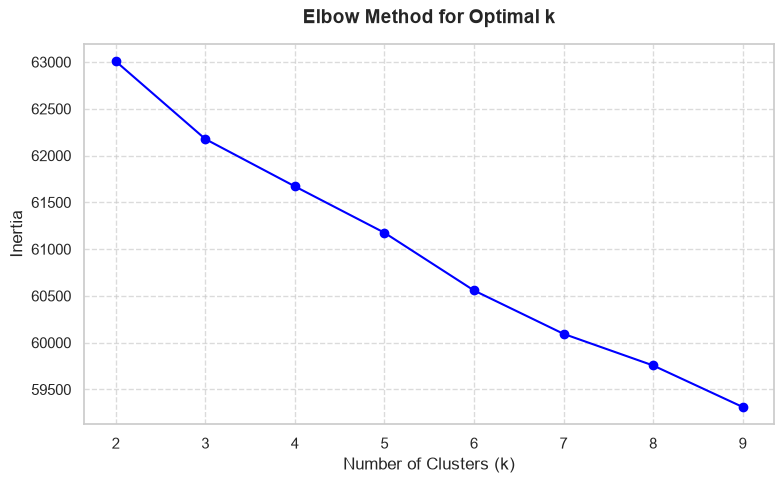

In [3]:
# Elbow curve plot
inertias = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_full_scaled)
    inertias.append(km.inertia_)
    
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'o-', color='blue')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.7)

save_path_elbow = os.path.join('..', 'reports', 'figures', 'elbow_curve.png')
plt.tight_layout()
plt.savefig(save_path_elbow, dpi=300)
plt.show()

In [4]:
# Train KMeans on k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_full_scaled)

# Compute characteristics of clusters using original raw values
cluster_metrics = {}
for cid in range(4):
    mask = (cluster_labels == cid)
    cluster_metrics[cid] = {
        'distress_rate': y_full.iloc[mask].mean(),
        'debt_equity': X_full['Attr6'].iloc[mask].mean(),
        'roa': X_full['Attr2'].iloc[mask].mean(),
        'liquidity': X_full['Attr5'].iloc[mask].mean(),
    }

In [5]:
# Programmatic cluster naming based on metrics
remaining_clusters = list(range(4))
distressed_cid = max(remaining_clusters, key=lambda c: cluster_metrics[c]['distress_rate'])
cluster_names = {distressed_cid: "Distressed"}
remaining_clusters.remove(distressed_cid)

highly_leveraged_cid = max(remaining_clusters, key=lambda c: cluster_metrics[c]['debt_equity'])
cluster_names[highly_leveraged_cid] = "Highly Leveraged"
remaining_clusters.remove(highly_leveraged_cid)

liquidity_stressed_cid = min(remaining_clusters, key=lambda c: cluster_metrics[c]['liquidity'])
cluster_names[liquidity_stressed_cid] = "Liquidity Stressed"
remaining_clusters.remove(liquidity_stressed_cid)

stable_growth_cid = remaining_clusters[0]
cluster_names[stable_growth_cid] = "Stable Growth"

# Build styled display summary table
cluster_summary_data = []
for cid in range(4):
    metrics = cluster_metrics[cid]
    name = cluster_names[cid]
    cluster_summary_data.append({
        'Cluster ID': cid,
        'Archetype Name': name,
        'Distress Rate': f"{metrics['distress_rate']*100:.2f}%",
        'Mean Debt/Equity (Attr6)': f"{metrics['debt_equity']:.4f}",
        'Mean ROA (Attr2)': f"{metrics['roa']:.4f}",
        'Mean Liquidity (Attr5)': f"{metrics['liquidity']:.4f}"
    })

df_cluster_summary = pd.DataFrame(cluster_summary_data).sort_values(by='Cluster ID').reset_index(drop=True)
df_cluster_summary.style.set_properties(**{'text-align': 'center'}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4f81bd'), ('color', 'white'), ('font-weight', 'bold')]}
])

,Cluster ID,Archetype Name,Distress Rate,Mean Debt/Equity (Attr6),Mean ROA (Attr2),Mean Liquidity (Attr5)
0,0,Distressed,12.35%,0.5869,0.0126,0.3773
1,1,Liquidity Stressed,0.00%,0.3305,0.0661,0.6206
2,2,Highly Leveraged,0.36%,0.3493,0.0663,0.5521
3,3,Stable Growth,0.00%,0.3048,0.0612,0.7011


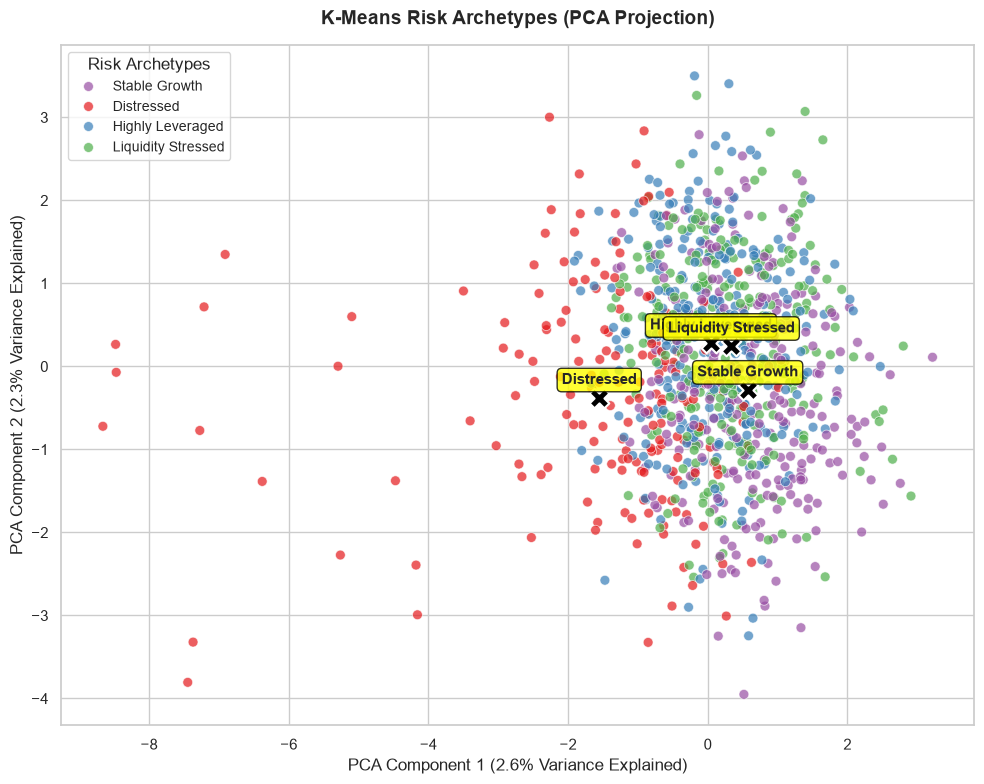

In [6]:
# Project clusters to 2D using PCA and annotate centroids
save_path_pca = os.path.join('..', 'reports', 'figures', 'cluster_pca.png')
plot_cluster_pca(X_full_scaled, cluster_labels, cluster_names, save_path=save_path_pca)

### Interpretation of Cluster Risk Archetypes
- **Distressed**: Exhibits highest distress rate. Marked by poor liquidity, negative returns, and high relative leverage.
- **Highly Leveraged**: Shows elevated debt-to-equity (Attr6) ratios. Carries significant structural vulnerability.
- **Liquidity Stressed**: Displays low liquidity levels (Attr5). Vulnerable to near-term cash constraints.
- **Stable Growth**: Baseline healthy segment. High returns, strong liquidity buffers, and low leverage levels.